In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
from sklearn.datasets import fetch_openml
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.decomposition import PCA

In [2]:
# Hämta MNIST-datasetet
mnist = fetch_openml('mnist_784', version=1, cache=True, as_frame=False)

# Definiera X och y
X = mnist["data"]
y = mnist["target"].astype(np.uint8)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Spara data och mål som NumPy-filer
np.save("X_mnist.npy",X)
np.save("y_mnist.npy", y)

# Kontrollera om några bilder är tomma (alla pixelvärden = 0)
empty_indices = np.where(X.sum(axis=1) == 0)[0]

# Skriv ut information om de tomma bilderna
print(f"Antal tomma bilder: {len(empty_indices)}")
print(f"Index för tomma bilder: {empty_indices}")

X shape: (70000, 784)
y shape: (70000,)
Antal tomma bilder: 0
Index för tomma bilder: []


In [9]:
# Fördela data i tränings- och en temporär uppsättning
X_train, X_temp, y_train, y_temp = train_test_split(X, y, train_size=0.7, random_state=42)

# Dela den temporära uppsättningen jämnt mellan validering och test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size = 0.5, random_state=42)

# Kontrollera storleken på alla dataset
print(f'Train data shape: {X_train.shape}, {y_train.shape}')
print(f'Validation data shape: {X_val.shape}, {y_val.shape}')
print(f'Test data shape: {X_test.shape}, {y_test.shape}')

Train data shape: (49000, 784), (49000,)
Validation data shape: (10500, 784), (10500,)
Test data shape: (10500, 784), (10500,)


In [ ]:
# andra steget uppdelning för att skapa tränings- och testuppsättningar (inför kommande testkörning)
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, train_size=60000/X.shape[0], random_state=42)

# Kontrollera storleken
print(f'Train+Validation data shape: {X_train_val.shape}, {y_train_val.shape}')
print(f'Test data shape: {X_test.shape}, {y_test.shape}')

Train+Validation data shape: (60000, 784), (60000,)
Test data shape: (10000, 784), (10000,)


In [5]:
k_values = [3,5,7,9]
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    print(f"K: {k}, Genomsnittlig noggrannhet: {scores.mean():.4f}")

K: 3, Genomsnittlig noggrannhet: 0.9687
K: 5, Genomsnittlig noggrannhet: 0.9679
K: 7, Genomsnittlig noggrannhet: 0.9670
K: 9, Genomsnittlig noggrannhet: 0.9655


In [37]:
knn = Pipeline([
    ('scaler', MinMaxScaler()),
    ('model', KNeighborsClassifier(n_neighbors=3, weights = 'distance', n_jobs =-1)) 
])
knn.fit(X_train, y_train)
score = knn.score(X_val, y_val)
print(f"KNN Score: {score:.4f}")
joblib.dump(knn, 'knn_optimerad.pkl')
print('Modellen är tränad och sparad')

KNN Score: 0.9722
Modellen är tränad och sparad


Träning av optimerad KNN-modell

In [7]:
k_values = ['distance','uniform', None]
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=3, weights = k, n_jobs =-1)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')
    print(f"K: {k}, Genomsnittlig noggrannhet: {scores.mean():.4f}")

K: distance, Genomsnittlig noggrannhet: 0.9702
K: uniform, Genomsnittlig noggrannhet: 0.9687
K: None, Genomsnittlig noggrannhet: 0.9687


Optimering av RandomForest modellen

In [17]:
n_estimators = [200,300, 400]

# Iterera över olika värden på n_estimators
for n in n_estimators:
    # Skapa pipeline
    rf = Pipeline([
    ('model', RandomForestClassifier(n_estimators = n, random_state=535, n_jobs=-1))
    ])
    scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
    print(f"n_estimators: {n}, Genomsnittlig noggrannhet: {scores.mean():.4f}")

n_estimators: 200, Genomsnittlig noggrannhet: 0.9674
n_estimators: 300, Genomsnittlig noggrannhet: 0.9675
n_estimators: 400, Genomsnittlig noggrannhet: 0.9678


In [29]:

learning_rate = [0.01, 0.1, 0.5, 1]

# Iterera över olika värden på learning_rate

for n in learning_rate:
    # Skapa pipeline
    hgbc = Pipeline([
    ('model', HistGradientBoostingClassifier(learning_rate = n, random_state=535, class_weight='balanced'))
    ])
    # Beräkna cross-validation-score
    scores = cross_val_score(hgbc, X_train, y_train, cv=5, scoring='accuracy')
    print(f"learning_rate: {n}, Genomsnittlig noggrannhet: {scores.mean():.4f}")

learning_rate: 0.01, Genomsnittlig noggrannhet: 0.9353
learning_rate: 0.1, Genomsnittlig noggrannhet: 0.9743
learning_rate: 0.5, Genomsnittlig noggrannhet: 0.8494
learning_rate: 1, Genomsnittlig noggrannhet: 0.7461


In [54]:
max_iter= [202,205]

# Iterera över olika värden på learning_rate

for n in max_iter:
    # Skapa pipeline
    hgbc = Pipeline([
    ('model', HistGradientBoostingClassifier(learning_rate = 0.1, max_iter=n, random_state=535, class_weight='balanced'))
    ])
    # Beräkna cross-validation-score
    scores = cross_val_score(hgbc, X_train, y_train, cv=5, scoring='accuracy')
    print(f"max:iter {n}, Genomsnittlig noggrannhet: {scores.mean():.4f}")

max:iter 202, Genomsnittlig noggrannhet: 0.9755


KeyboardInterrupt: 

max_depth: 26, Genomsnittlig noggrannhet: 0.9666
max_depth: 27, Genomsnittlig noggrannhet: 0.9674


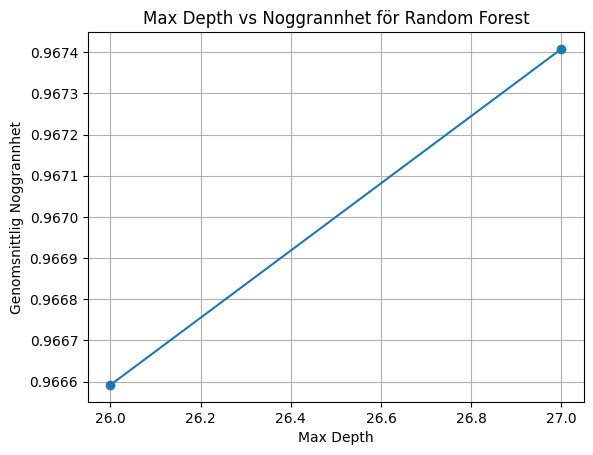

In [ ]:
# Parametervärden att testa
k_values = range(26, 28)  # Exempel för max_depth

# Lista för att lagra genomsnittliga poäng 
mean_scores = []

# Loopa över varje k-värde
for k in k_values:
    rf = RandomForestClassifier(n_estimators=200, max_depth=k, random_state=42, class_weight="balanced")
    scores = cross_val_score(rf, X_train, y_train, cv=5, scoring='accuracy')
    mean_scores.append(scores.mean())
    print(f"max_depth: {k}, Genomsnittlig noggrannhet: {scores.mean():.4f}")

Träning av optimerad RanodomForest med de nya hyperparametrarna, n_estimator och max_depth

In [43]:
rf = Pipeline([
    ('model', RandomForestClassifier(n_jobs=-1))
])
rf.fit(X_train, y_train)
score = rf.score(X_val, y_val)
joblib.dump(rf, 'rf_optimerad.pkl')
print(f"RandomForest: {score:.4f}")

RandomForest: 0.9660


Träning av optimerad HistGradientBoostingClassifier med de nya hyperparametrarna för learning_rate och max_iter

In [33]:
hgbc = Pipeline([
    ('model', HistGradientBoostingClassifier(learning_rate = 0.1, max_iter=203, random_state=535, class_weight='balanced'))
    ])
hgbc.fit(X_train, y_train)
score = hgbc.score(X_val, y_val)
print(f"hgbc Score: {score:.4f}")
joblib.dump(hgbc, 'hgbc_optimerad.pkl')
print('Modellen är tränad och sparad')

hgbc Score: 0.9782
Modellen är tränad och sparad


In [8]:
knn = Pipeline([
    ('model', KNeighborsClassifier(n_neighbors=3, weights ='distance',n_jobs = -1)) 
])
knn.fit(X_train, y_train)
score = knn.score(X_val, y_val)
print(f"KNN Score: {score:.4f}")
joblib.dump(knn, 'knn_optimerad.pkl')
print('Modellen är tränad och sparad')

KNN Score: 0.9722
Modellen är tränad och sparad


In [37]:
# Ladda upp den sparade modellen
rf = joblib.load('rf_optimerad.pkl')
# Generera prediktioner på valideringsdatan
y_pred = rf.predict(X_val)
# Skapa klassificeringsrapport
report = classification_report(y_val, y_pred, output_dict=True)

# Skriv ut rapporten
print("Klassificeringsrapport:")
print(classification_report(y_val, y_pred))

# Spara rapporten med joblib
joblib.dump(report, 'rf_class_report.pkl')
print('Klassificeringsrapporten är nu sparad som rf_class_report.pkl')

Klassificeringsrapport:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1022
           1       0.98      0.98      0.98      1138
           2       0.95      0.97      0.96      1084
           3       0.96      0.95      0.95      1046
           4       0.96      0.97      0.97       963
           5       0.97      0.96      0.97       953
           6       0.98      0.98      0.98      1085
           7       0.97      0.96      0.97      1162
           8       0.96      0.95      0.95       999
           9       0.94      0.95      0.95      1048

    accuracy                           0.97     10500
   macro avg       0.97      0.97      0.97     10500
weighted avg       0.97      0.97      0.97     10500

Klassificeringsrapporten är nu sparad som rf_class_report.pkl


In [ ]:
# Ladda modellen
hgbc = joblib.load('hgbc_optimerad.pkl')

# Generera prediktioner på valideringsdatan
y_pred = hgbc.predict(X_val)

# Skapa classification report som dictionary
report = classification_report(y_val, y_pred, output_dict=True)

# Skriv ut rapporten
print("Klassificeringsrapport:")
print(classification_report(y_val, y_pred))

# Spara rapporten med joblib
joblib.dump(report, 'hgbc_class_report.pkl')
print('Klassificeringsrapporten är nu sparad som hgbc_class_report.pkl!')

Klassificeringsrapport:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1022
           1       0.99      0.99      0.99      1138
           2       0.97      0.97      0.97      1084
           3       0.97      0.96      0.97      1046
           4       0.98      0.98      0.98       963
           5       0.98      0.98      0.98       953
           6       0.99      0.99      0.99      1085
           7       0.98      0.98      0.98      1162
           8       0.97      0.98      0.97       999
           9       0.96      0.97      0.97      1048

    accuracy                           0.98     10500
   macro avg       0.98      0.98      0.98     10500
weighted avg       0.98      0.98      0.98     10500

Klassificeringsrapporten är nu sparad som hgbc_class_report.pkl!


In [38]:
# Ladda upp den sparade modellen
knn = joblib.load('knn_optimerad.pkl')

# Generera prediktioner på valideringsdatan
y_pred = knn.predict(X_val)
# Skapa classification report som dictionary
report = classification_report(y_val, y_pred, output_dict=True)

# Skriv ut rapporten
print("Klassificeringsrapport:")
print(classification_report(y_val, y_pred))

# Spara rapporten med joblib
joblib.dump(report, 'knn_class_report.pkl')
print('Klassificeringsrapporten är nu sparad som knn_class_report.pkl')

Klassificeringsrapport:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1022
           1       0.96      0.99      0.98      1138
           2       0.98      0.96      0.97      1084
           3       0.97      0.96      0.96      1046
           4       0.98      0.97      0.97       963
           5       0.97      0.97      0.97       953
           6       0.98      0.99      0.99      1085
           7       0.97      0.97      0.97      1162
           8       0.98      0.94      0.96       999
           9       0.96      0.96      0.96      1048

    accuracy                           0.97     10500
   macro avg       0.97      0.97      0.97     10500
weighted avg       0.97      0.97      0.97     10500

Klassificeringsrapporten är nu sparad som knn_class_report.pkl


In [ ]:
# Ladda sparade modeller
hgbc = joblib.load('hgbc_optimerad.pkl')
knn = joblib.load('knn_optimerad.pkl')  # Se till att du sparat KNN-modellen
rf = joblib.load('rf_optimerad.pkl')    # Se till att du sparat RandomForest-modellen

# Skapa en voter
voter = VotingClassifier(estimators=[
    ('hgbc', hgbc),
    ('knn', knn),
    ('rf', rf)
], voting='soft')  # Soft voting använder sannolikheter för bättre prestanda

# Träna votern
voter.fit(X_train, y_train)

# Utvärdera votern och generera en klassificeringsrapport som en dictionary
report = classification_report(y_val, y_pred, output_dict=True)

# Skriv ut klassificeringspoängen
print(f"Voting Classifier Score: {score:.4f}")

# Spara Voting Classifier-modell som en pickle-fil
joblib.dump(voter, 'voting_classifier.pkl')
print('Voting Classifier är sparad som voting_classifier.pkl')

Voting Classifier Score: 0.9803
Voting Classifier är sparad som voting_classifier.pkl


In [ ]:
# Ladda modellen
hgbc = joblib.load('hgbc_optimerad.pkl')

#träning om modellen på kombbinerat train och valideringsdata
hgbc.fit(X_train_val, y_train_val)

#spara modellen efter träning på kombinerat train och valideringsdata
joblib.dump(hgbc, 'hgbc_full_dataset.pkl')
print('Modellen är tränad och sparad')

Modellen är tränad och sparad


In [51]:
y_pred = hgbc.predict(X_test)
# Skapa classification report som dictionary
report = classification_report(y_test, y_pred, output_dict=True)

# Skriv ut rapporten
print("Klassificeringsrapport:")
print(classification_report(y_test, y_pred))

# Spara rapporten med joblib
joblib.dump(report, 'class_report2.pkl')
print('cr för HistGradientBooster  är nu sparad som class2_report.pkl')

Klassificeringsrapport:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       983
           1       0.99      0.99      0.99      1152
           2       0.96      0.98      0.97       967
           3       0.98      0.97      0.98      1034
           4       0.98      0.98      0.98       906
           5       0.98      0.98      0.98       937
           6       0.99      0.99      0.99       961
           7       0.97      0.98      0.98      1055
           8       0.97      0.97      0.97       969
           9       0.97      0.97      0.97      1036

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

cr för HistGradientBooster  är nu sparad som class2_report.pkl


In [49]:
# Ladda modellen
combimodell = joblib.load('voting_classifier.pkl')
combimodell.fit(X_train_val, y_train_val)
joblib.dump(combimodell, 'combimodell_full_dataset.pkl')
print('Modellen är tränad och sparad')

Modellen är tränad och sparad


In [50]:
y_pred = combimodell.predict(X_test)
# Skapa classification report som dictionary
report = classification_report(y_test, y_pred, output_dict=True)

# Skriv ut rapporten
print("Klassificeringsrapport:")
print(classification_report(y_test, y_pred))

# Spara rapporten med joblib
joblib.dump(report, 'class_report1.pkl')
print('cr för Kombimodellen  är nu sparad som class_report.pkl')

Klassificeringsrapport:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       983
           1       0.98      0.99      0.99      1152
           2       0.97      0.99      0.98       967
           3       0.98      0.97      0.97      1034
           4       0.98      0.98      0.98       906
           5       0.99      0.98      0.98       937
           6       0.99      0.99      0.99       961
           7       0.97      0.98      0.98      1055
           8       0.99      0.97      0.98       969
           9       0.98      0.97      0.97      1036

    accuracy                           0.98     10000
   macro avg       0.98      0.98      0.98     10000
weighted avg       0.98      0.98      0.98     10000

cr för Kombimodellen  är nu sparad som class_report.pkl


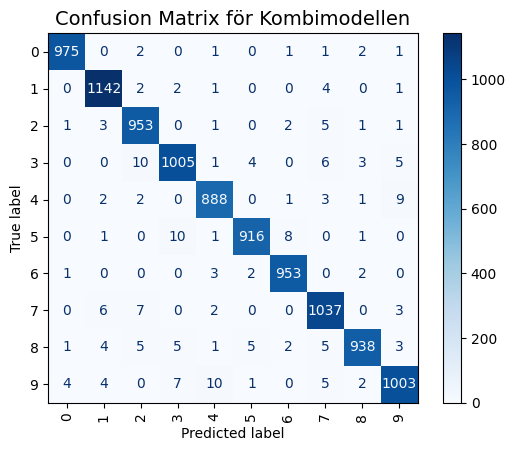

In [ ]:
# Förutsägelser på testdatan
y_pred = combimodell.predict(X_test)

# Skapa confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualisera confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(y_test))
disp.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix för Kombimodellen', fontsize=14)
plt.show()


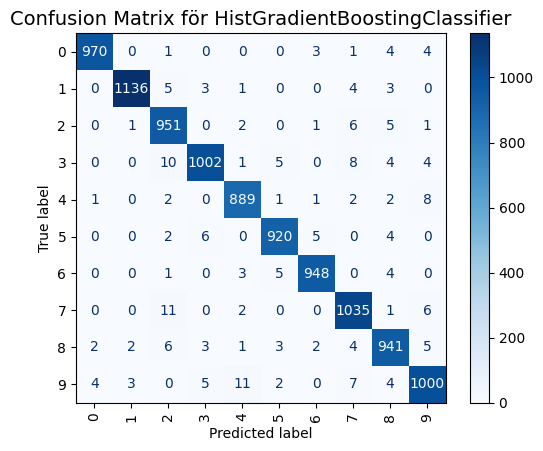

In [ ]:
# Förutsägelser på testdatan för den andra modellen
y_pred_hgbc = hgbc.predict(X_test)

# Skapa confusion matrix
cm_hgbc = confusion_matrix(y_test, y_pred_hgbc)

# Visualisera confusion matrix
disp_hgbc = ConfusionMatrixDisplay(confusion_matrix=cm_hgbc, display_labels=np.unique(y_test))
disp_hgbc.plot(cmap='Blues', xticks_rotation='vertical')
plt.title('Confusion Matrix för HistGradientBoostingClassifier', fontsize=14)
plt.show()

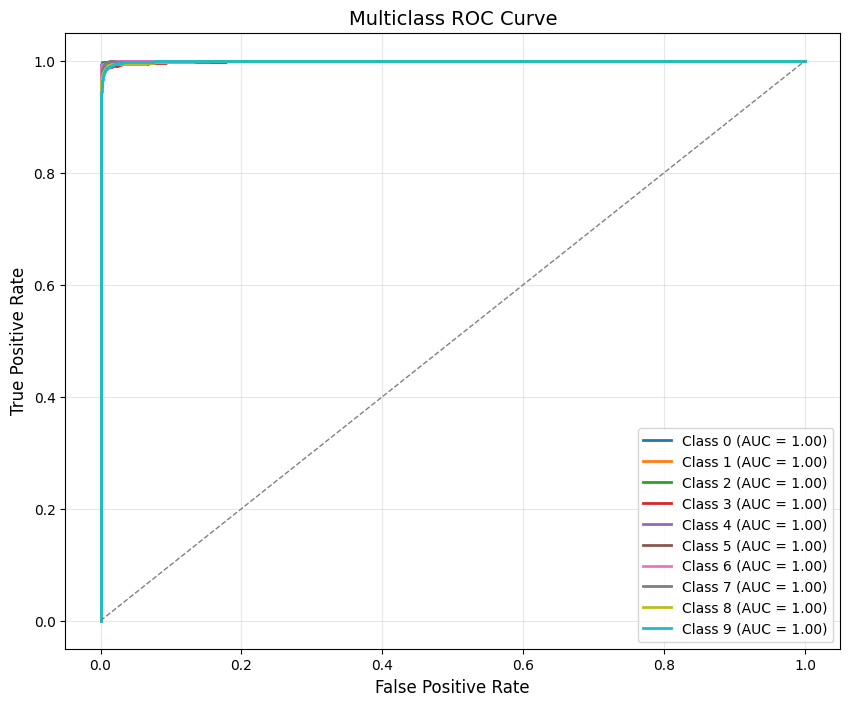

In [ ]:
# Binarisera etiketterna
classes = np.unique(y_test)  # Alla klasser
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Prediktera sannolikheter
y_probs = combimodell.predict_proba(X_test)

# Plotta ROC-kurvan för varje klass
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

# Lägg till en diagonal referenslinje
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)

# Inställningar för grafen
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multiclass ROC Curve', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

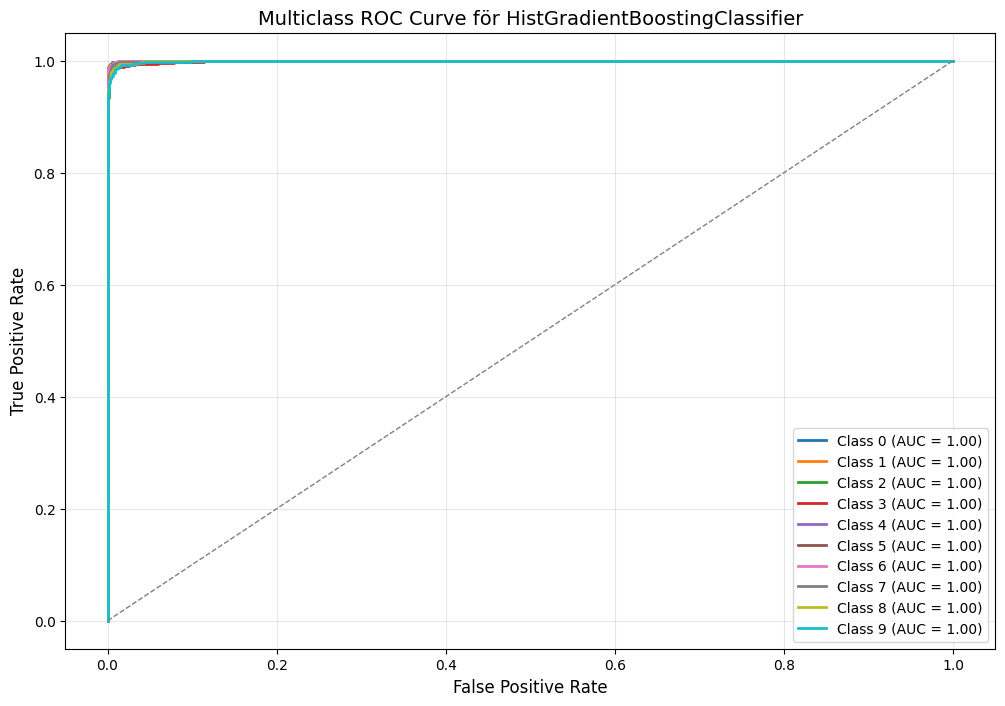

In [ ]:
# Binarisera etiketterna (för klasser 0-9)
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)
n_classes = y_test_bin.shape[1]

# Prediktera sannolikheter
y_probs = hgbc.predict_proba(X_test)  # Sannolikheter för alla klasser

# Plotta ROC-kurvor för varje klass
plt.figure(figsize=(12, 8))
for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'Class {classes[i]} (AUC = {roc_auc:.2f})')

# Lägg till en diagonal referenslinje
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)

# Justera grafens utformning
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Multiclass ROC Curve för HistGradientBoostingClassifier', fontsize=14)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()